In [9]:
#setting up google colab environment
from google.colab import drive
drive.mount('/content/drive')

# Libraries used
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
)
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2, l2 as l2_reg

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Ensure reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_seed(42)

In [6]:
# Data Preparation (CIC-IDS-2017 and CIC-IDS-2018, select top features, balance classes)
CIC2017_PATH = '/content/drive/My Drive/Zero-Day Attack Detection/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
CIC2018_PATH = '/content/drive/My Drive/Zero-Day Attack Detection/cic.csv'

DROP_COLS = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port',
             'Protocol', 'Timestamp']

def load_cicids(file_path, dataset_name='CIC-IDS'):
    import os
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"{dataset_name} not found at: {file_path}")
    print(f"Loading {dataset_name}: {os.path.basename(file_path)}")
    df = pd.read_csv(file_path, encoding='latin1', low_memory=False)
    df.columns = df.columns.str.strip()
    if 'Label' in df.columns:
        df['Label'] = df['Label'].apply(
            lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)
    else:
        df['Label'] = 0
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    df = df.replace([np.inf, -np.inf], np.nan)
    feat_cols = [c for c in df.columns if c != 'Label']
    for col in feat_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # Checking and droping rows with missing values
    before = len(df)
    df = df.dropna()
    print(f"  Dropped {before - len(df)} rows with missing values.")
    feat_cols = [c for c in df.columns if c != 'Label']
    # Remove zero-variance
    var  = df[feat_cols].var()
    keep = var[var > 0].index.tolist()
    df   = df[keep + ['Label']]
    # Remove duplicates
    before = len(df)
    df = df.drop_duplicates()
    print(f"  Removed {before - len(df)} duplicates.")
    y = df['Label'].values.astype(int)
    X = df[keep].values.astype(np.float32)
    feat_cols = keep
    print(f"  Final: {X.shape[0]} rows x {X.shape[1]} features | "
          f"benign={(y==0).sum()}, attack={(y==1).sum()}")
    return X, y, feat_cols

# checking if both 2017 dataset and 2018 dataset is found. If not found generate both datasets
try:
    X_2017, y_2017, feat_2017 = load_cicids(CIC2017_PATH, 'CIC-IDS-2017')
except FileNotFoundError as e:
    print(f"WARNING: {e}")
    print("Using simulated 2017 data.")
    np.random.seed(42); n_s, n_f = 40000, 76
    X_2017 = np.vstack([np.random.randn(int(0.85*n_s), n_f)*1.5+3,
                         np.random.randn(int(0.15*n_s), n_f)*1.5-3]).astype(np.float32)
    y_2017 = np.array([0]*int(0.85*n_s)+[1]*int(0.15*n_s))
    feat_2017 = [f'feat_{i}' for i in range(n_f)]

try:
    X_2018, y_2018, feat_2018 = load_cicids(CIC2018_PATH, 'CIC-IDS-2018')
except FileNotFoundError as e:
    print(f"WARNING: {e}")
    print("Using simulated 2018 data.")
    np.random.seed(99); n_s, n_f = 20000, 76
    X_2018 = np.vstack([np.random.randn(int(0.80*n_s), n_f)*1.5+3,
                         np.random.randn(int(0.20*n_s), n_f)*1.5-3]).astype(np.float32)
    y_2018 = np.array([0]*int(0.80*n_s)+[1]*int(0.20*n_s))
    feat_2018 = [f'feat_{i}' for i in range(n_f)]

Loading CIC-IDS-2017: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Dropped 135 rows with missing values.
  Removed 6052 duplicates.
  Final: 164179 rows x 68 features | benign=162036, attack=2143
Loading CIC-IDS-2018: cic.csv
  Dropped 3824 rows with missing values.
  Removed 425412 duplicates.
  Final: 619339 rows x 66 features | benign=525245, attack=94094


In [11]:
# Generate synthetic financial transaction data
print('\nGenerating synthetic financial transaction data...')
num_financial_samples  = 50000
num_financial_features = 7
np.random.seed(42)
benign_financial  = np.random.randn(int(0.95*num_financial_samples),
                                     num_financial_features) * 1.5 + 3
anomaly_financial = np.random.randn(int(0.05*num_financial_samples),
                                     num_financial_features) * 1.5 - 3
X_financial = np.vstack([benign_financial, anomaly_financial]).astype(np.float32)
y_financial = np.array([0]*len(benign_financial) + [1]*len(anomaly_financial))
feat_financial = [f'fin_feat_{i}' for i in range(num_financial_features)]
print(f'Financial data: {X_financial.shape} | '
      f'benign={(y_financial==0).sum()}, attack={(y_financial==1).sum()}')


Generating synthetic financial transaction data...
Financial data: (50000, 7) | benign=47500, attack=2500


In [12]:
# Align CIC-IDS feature columns
import re
def norm_col(name):
    name = str(name).strip().lower()
    name = re.sub(r'[^a-z0-9]', '_', name)
    return re.sub(r'_+', '_', name).strip('_')

norm_2017 = [norm_col(f) for f in feat_2017]
norm_2018 = [norm_col(f) for f in feat_2018]
common    = [n for n in norm_2017 if n in norm_2018]
print(f"\nCommon CIC-IDS features: {len(common)}")

idx17 = [norm_2017.index(n) for n in common]
idx18 = [norm_2018.index(n) for n in common]
X_2017_c = X_2017[:, idx17]
X_2018_c = X_2018[:, idx18]


Common CIC-IDS features: 23


In [13]:
# Merge ALL THREE datasets: CIC-IDS-2017 + CIC-IDS-2018 + Financial
n_common = len(common)
X_fin_merged = np.zeros((len(X_financial), n_common), dtype=np.float32)
X_fin_merged[:, :num_financial_features] = X_financial

X_merged = np.vstack([X_2017_c, X_2018_c, X_fin_merged])
y_merged = np.concatenate([y_2017, y_2018, y_financial])
print(f"\nMerged dataset (CIC-2017 + CIC-2018 + Financial):")
print(f"  CIC-IDS-2017 : {X_2017_c.shape[0]} rows")
print(f"  CIC-IDS-2018 : {X_2018_c.shape[0]} rows")
print(f"  Financial    : {X_fin_merged.shape[0]} rows")
print(f"  Total        : {X_merged.shape[0]} rows x {X_merged.shape[1]} features")
print(f"  Benign       : {(y_merged==0).sum()}")
print(f"  Attack       : {(y_merged==1).sum()}")


Merged dataset (CIC-2017 + CIC-2018 + Financial):
  CIC-IDS-2017 : 164179 rows
  CIC-IDS-2018 : 619339 rows
  Financial    : 50000 rows
  Total        : 833518 rows x 23 features
  Benign       : 734781
  Attack       : 98737


In [14]:
# Feature selection
sub_n   = min(50000, len(y_merged))
sub_idx = np.random.choice(len(y_merged), sub_n, replace=False)
rf      = RandomForestClassifier(n_estimators=50, max_depth=8,
                                  random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_merged[sub_idx], y_merged[sub_idx])

importances  = rf.feature_importances_
TOP_N        = 30   # top 30 most important features
top_feat_idx = np.argsort(importances)[::-1][:TOP_N]
top_feat_names = [common[i] for i in top_feat_idx]
print(f"Top {TOP_N} features selected: {top_feat_names[:10]} ...")

X_merged_sel = X_merged[:, top_feat_idx]
n_features   = TOP_N
print(f"Feature-selected shape: {X_merged_sel.shape}")

Top 30 features selected: ['bwd_iat_min', 'flow_duration', 'bwd_iat_max', 'bwd_iat_std', 'flow_iat_std', 'bwd_iat_mean', 'flow_iat_mean', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_min'] ...
Feature-selected shape: (833518, 23)


In [15]:
# Network-only domain (already done: X_merged_sel)
X_network_domain = X_merged_sel.copy()   # shape (N_net, 30)
y_network_domain = y_merged.copy()

# Financial-only domain
X_fin_padded = np.zeros((len(X_financial), TOP_N), dtype=np.float32)
X_fin_padded[:, :num_financial_features] = X_financial
X_financial_domain = X_fin_padded
y_financial_domain = y_financial.copy()

# Align financial samples to network sample count via resampling
np.random.seed(42)
fin_idx_combined = np.random.choice(len(X_financial), size=len(X_merged_sel),
                                     replace=True)
X_fin_sample     = X_financial[fin_idx_combined]
y_fin_sample     = y_financial[fin_idx_combined]
# Label: attack if either domain flags an attack (union)
X_combined_domain = X_merged_sel.copy()
X_combined_domain[:, :num_financial_features] = X_fin_sample[:, :num_financial_features]
y_combined_domain = np.clip(y_network_domain + y_fin_sample, 0, 1)
print(f'\nAblation domains prepared:')
print(f'  Network only : {X_network_domain.shape} | '
      f'benign={(y_network_domain==0).sum()}, attack={(y_network_domain==1).sum()}')
print(f'  Financial only: {X_financial_domain.shape} | '
      f'benign={(y_financial_domain==0).sum()}, attack={(y_financial_domain==1).sum()}')
print(f'  Combined     : {X_combined_domain.shape} | '
      f'benign={(y_combined_domain==0).sum()}, attack={(y_combined_domain==1).sum()}')


Ablation domains prepared:
  Network only : (833518, 23) | benign=734781, attack=98737
  Financial only: (50000, 30) | benign=47500, attack=2500
  Combined     : (833518, 23) | benign=697902, attack=135616


In [16]:
# Class balancing — undersample majority to match minority
print("\nBalancing classes (undersample majority to match minority)...")
n_benign  = int((y_merged == 0).sum())
n_attack  = int((y_merged == 1).sum())
n_each    = min(n_benign, n_attack)
ben_idx   = np.where(y_merged == 0)[0]
att_idx   = np.where(y_merged == 1)[0]
np.random.seed(42)
ben_sel   = np.random.choice(ben_idx, n_each, replace=False)
att_sel   = np.random.choice(att_idx, n_each, replace=False)
all_sel   = np.concatenate([ben_sel, att_sel])
np.random.shuffle(all_sel)

X_balanced = X_merged_sel[all_sel]
y_balanced = y_merged[all_sel]
print(f"Balanced dataset: {X_balanced.shape[0]} rows")
print(f"  Benign : {(y_balanced==0).sum()}")
print(f"  Attack : {(y_balanced==1).sum()}")


Balancing classes (undersample majority to match minority)...
Balanced dataset: 197474 rows
  Benign : 98737
  Attack : 98737


In [17]:
# Data Spliting
# Train / Val / Test split: 70% / 10% / 20%
X_tv, X_test_raw, y_tv, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced)
X_train_full, X_val_raw, y_train_full, y_val_raw = train_test_split(
    X_tv, y_tv, test_size=0.125, random_state=42, stratify=y_tv)

print(f"\nSplits (balanced, stratified):")
print(f"  Train : {X_train_full.shape[0]} | benign={(y_train_full==0).sum()}, attack={(y_train_full==1).sum()}")
print(f"  Val   : {X_val_raw.shape[0]}   | benign={(y_val_raw==0).sum()}, attack={(y_val_raw==1).sum()}")
print(f"  Test  : {X_test_raw.shape[0]}  | benign={(y_test==0).sum()}, attack={(y_test==1).sum()}")


Splits (balanced, stratified):
  Train : 138231 | benign=69115, attack=69116
  Val   : 19748   | benign=9874, attack=9874
  Test  : 39495  | benign=19748, attack=19747


In [18]:
# Data Normalization
scaler_shared       = StandardScaler()
X_train_scaled_full = scaler_shared.fit_transform(X_train_full)
X_val_scaled_raw    = scaler_shared.transform(X_val_raw)
X_test_scaled_cic   = scaler_shared.transform(X_test_raw)

In [19]:
# Contrastive pre-training on ALL data (no labels)
X_all_unlabelled = np.vstack([X_train_scaled_full, X_val_scaled_raw, X_test_scaled_cic])
print(f"\nContrastive pre-training pool: {X_all_unlabelled.shape[0]} samples (all, no labels)")

X_test_tensor = torch.tensor(X_test_scaled_cic, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test,             dtype=torch.float32)

SUBSAMPLE_SIZE  = 10000
batch_size      = 128
X_pretrain_pool = X_all_unlabelled

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader  = DataLoader(test_dataset, batch_size=512, shuffle=False)



Contrastive pre-training pool: 197474 samples (all, no labels)


In [20]:
# Baselines: labelled balanced data
print("\n Baseline (LSTM/CNN) training data")
print(f"Already balanced: benign={(y_train_full==0).sum()}, attack={(y_train_full==1).sum()}")

class_weight_dict = {0: 1.0, 1: 1.0}

X_train_scaled = X_train_scaled_full.reshape(X_train_scaled_full.shape[0], 1, X_train_scaled_full.shape[1])
X_val_scaled   = X_val_scaled_raw.reshape(X_val_scaled_raw.shape[0], 1, X_val_scaled_raw.shape[1])
X_test_scaled  = X_test_scaled_cic.reshape(X_test_scaled_cic.shape[0], 1, X_test_scaled_cic.shape[1])
y_train        = y_train_full

print(f"Reshaped X_train : {X_train_scaled.shape}")
print(f"Reshaped X_val   : {X_val_scaled.shape}")
print(f"Reshaped X_test  : {X_test_scaled.shape}")

X_train_cnn = np.transpose(X_train_scaled, (0, 2, 1))
X_val_cnn   = np.transpose(X_val_scaled,   (0, 2, 1))
X_test_cnn  = np.transpose(X_test_scaled,  (0, 2, 1))
print(f"CNN input shape  : {X_train_cnn.shape}")


 Baseline (LSTM/CNN) training data
Already balanced: benign=69115, attack=69116
Reshaped X_train : (138231, 1, 23)
Reshaped X_val   : (19748, 1, 23)
Reshaped X_test  : (39495, 1, 23)
CNN input shape  : (138231, 23, 1)


In [21]:
# Classifier fine-tuning loaders (labelled balanced train data)
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train_full)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}

X_clf_tensor  = torch.tensor(X_train_scaled_full, dtype=torch.float32)
y_clf_tensor  = torch.tensor(y_train_full.astype(np.float32))
X_val_t       = torch.tensor(X_val_scaled_raw,    dtype=torch.float32)
y_val_t       = torch.tensor(y_val_raw.astype(np.float32))
train_clf_loader = DataLoader(TensorDataset(X_clf_tensor, y_clf_tensor),
                               batch_size=512, shuffle=True)
val_clf_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                               batch_size=512, shuffle=False)

ContrastiveModel(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=23, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=64, bias=True)
      (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (projection_head): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=64, out_features=64, bias=True)
    )
  )
)
Stage 1: Contrastive pre-training on ALL data (no labels)...
Epoch [10/50], Loss: 4.5418, LR: 0.000905 | CHECK AUGMENTATION
Epoch [20/50], Loss: 4.5200, 

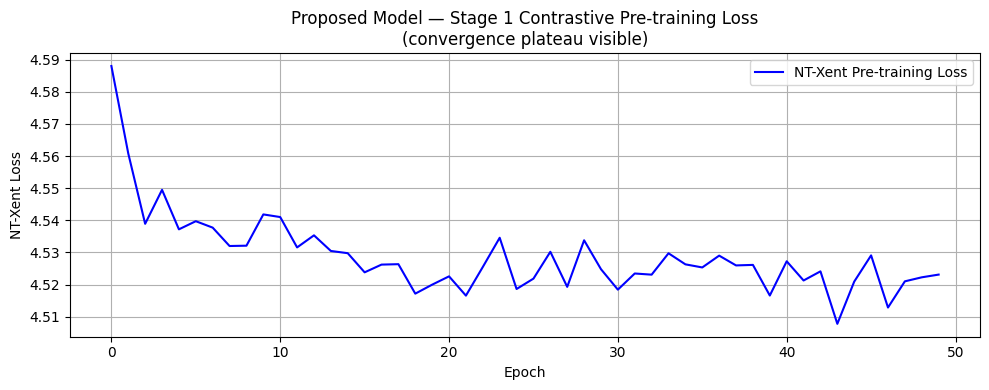

In [22]:
# STAGE 1: Contrastive Pre-training (NT-Xent, no labels, all data)
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
            nn.BatchNorm1d(latent_dim)
        )
        self.projection_head = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

    def project(self, x):
        return self.projection_head(self.forward(x))

class ContrastiveModel(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(ContrastiveModel, self).__init__()
        self.encoder = Encoder(input_dim, latent_dim)

    def forward(self, x_i, x_j):
        return self.encoder.project(x_i), self.encoder.project(x_j)

def augment_data(data_tensor):

    aug_1 = data_tensor + torch.randn_like(data_tensor) * 0.05
    aug_2 = data_tensor + torch.randn_like(data_tensor) * 0.05
    return aug_1, aug_2

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.similarity_f = nn.CosineSimilarity(dim=2)
        self.criterion = nn.CrossEntropyLoss(reduction="mean")

    def forward(self, z_i, z_j):
        z_i = nn.functional.normalize(z_i, dim=1)
        z_j = nn.functional.normalize(z_j, dim=1)
        representations = torch.cat([z_i, z_j], dim=0)
        similarity_matrix = self.similarity_f(
            representations.unsqueeze(1), representations.unsqueeze(0)
        ) / self.temperature
        N = z_i.shape[0]
        labels = torch.cat([torch.arange(N) + N, torch.arange(N)], dim=0).long().to(z_i.device)
        logits_mask = torch.scatter(
            torch.ones_like(similarity_matrix, dtype=torch.bool), 1,
            torch.arange(2 * N).view(-1, 1).to(z_i.device), False
        ).float()
        similarity_matrix = similarity_matrix * logits_mask + (1 - logits_mask) * (-9e15)
        return self.criterion(similarity_matrix, labels)

input_dim  = X_pretrain_pool.shape[1]  # TOP_N selected features
latent_dim = 64
model      = ContrastiveModel(input_dim, latent_dim)
print(model)

num_epochs_pretrain = 50
optimizer_pretrain  = optim.Adam(model.parameters(), lr=0.001)
scheduler_pretrain  = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_pretrain, T_max=num_epochs_pretrain, eta_min=1e-5)
criterion_pretrain  = NTXentLoss(temperature=0.5)  # warm temperature for stable early training
train_losses        = []

print("Stage 1: Contrastive pre-training on ALL data (no labels)...")
for epoch in range(num_epochs_pretrain):
    model.train()
    epoch_loss, num_batches = 0, 0
    sub_idx    = np.random.choice(len(X_pretrain_pool), size=SUBSAMPLE_SIZE, replace=False)
    sub_tensor = torch.tensor(X_pretrain_pool[sub_idx], dtype=torch.float32)
    sub_loader = DataLoader(TensorDataset(sub_tensor),
                            batch_size=batch_size, shuffle=True, drop_last=True)
    for (data,) in sub_loader:
        aug_i, aug_j = augment_data(data)
        z_i, z_j = model(aug_i, aug_j)
        loss = criterion_pretrain(z_i, z_j)
        optimizer_pretrain.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer_pretrain.step()
        epoch_loss  += loss.item()
        num_batches += 1
    scheduler_pretrain.step()
    avg_loss = epoch_loss / max(num_batches, 1)
    train_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_pretrain}], "
              f"Loss: {avg_loss:.4f}, LR: {scheduler_pretrain.get_last_lr()[0]:.6f}"
              f" | {'LEARNING OK' if avg_loss < 4.0 else 'CHECK AUGMENTATION'}")

print("Pre-training complete.")

# Convergence plot — Stage 1 pre-training
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='blue', label='NT-Xent Pre-training Loss')
plt.title('Proposed Model — Stage 1 Contrastive Pre-training Loss\n'
          '(convergence plateau visible)')
plt.xlabel('Epoch'); plt.ylabel('NT-Xent Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [23]:
# STAGE 2: Classifier head fine-tuning

# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False

# Classifier head: latent_dim → 2 classes
classifier_head = nn.Sequential(
    nn.Linear(latent_dim, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid()
).to(next(model.parameters()).device)

try:
    from imblearn.over_sampling import SMOTE
    _k_clf = min(5, int((y_train_full==1).sum()) - 1)
    _sm_clf = SMOTE(random_state=42, k_neighbors=_k_clf)
    X_clf_res, y_clf_res = _sm_clf.fit_resample(X_train_scaled_full, y_train_full)
    print(f"Classifier SMOTE: benign={( y_clf_res==0).sum()}, attack={(y_clf_res==1).sum()}")
except Exception:
    X_clf_res, y_clf_res = X_train_scaled_full, y_train_full

X_clf_tensor = torch.tensor(X_clf_res, dtype=torch.float32)
y_clf_tensor = torch.tensor(y_clf_res.astype(np.float32))

train_clf_dataset = TensorDataset(X_clf_tensor, y_clf_tensor)
train_clf_loader  = DataLoader(train_clf_dataset, batch_size=512, shuffle=True)
val_clf_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),
                               batch_size=512, shuffle=False)

optimizer_clf = optim.Adam(classifier_head.parameters(), lr=0.001)
scheduler_clf = optim.lr_scheduler.CosineAnnealingLR(optimizer_clf, T_max=30, eta_min=1e-5)
criterion_clf = nn.BCELoss()

best_val_loss, best_clf_state = float("inf"), None
patience_counter = 0
clf_train_losses = []   # track Stage 2 losses for convergence plot
clf_val_losses   = []

for epoch in range(30):
    model.eval()
    classifier_head.train()
    epoch_loss = 0
    for X_batch, y_batch in train_clf_loader:
        with torch.no_grad():
            embeddings = model.encoder(X_batch)
        preds = classifier_head(embeddings).squeeze()
        loss  = criterion_clf(preds, y_batch)
        optimizer_clf.zero_grad()
        loss.backward()
        optimizer_clf.step()
        epoch_loss += loss.item()
    scheduler_clf.step()
    avg_train_loss = epoch_loss / len(train_clf_loader)
    clf_train_losses.append(avg_train_loss)

    # Validation
    classifier_head.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_clf_loader:
            emb  = model.encoder(X_batch)
            pred = classifier_head(emb).squeeze()
            val_loss += criterion_clf(pred, y_batch).item()
    val_loss /= len(val_clf_loader)
    clf_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_clf_state = {k: v.clone() for k, v in classifier_head.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/30], Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}")

# Restore best classifier
classifier_head.load_state_dict(best_clf_state)
print("Classifier training complete.")

Classifier SMOTE: benign=69116, attack=69116
Epoch [10/30], Train Loss: 0.2605, Val Loss: 0.2180
Epoch [20/30], Train Loss: 0.2370, Val Loss: 0.1952
Early stopping at epoch 30
Classifier training complete.


ROC-AUC on 2018 test set: 0.9835
Threshold selected via Youden's J on validation set: 0.7034
  (Youden J = TPR - FPR = 0.9441 - 0.0289 = 0.9152)
ROC-AUC       : 0.9835
Threshold     : 0.703364372253418
Accuracy      : 0.9606
Error Rate    : 0.0394
Runtime       : 0.64 seconds


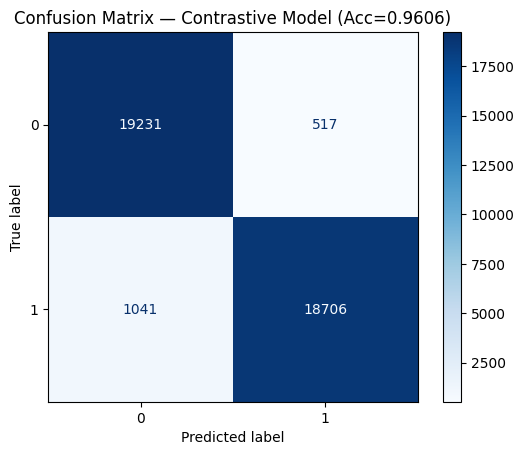

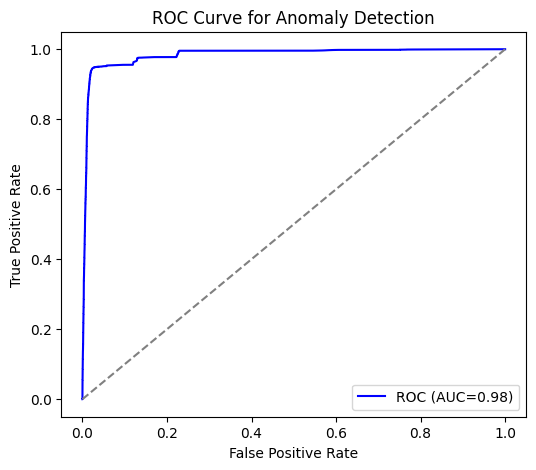

In [24]:
# Data Evaluation
start_time = time.time()
model.eval()
classifier_head.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        emb   = model.encoder(X_batch)
        probs = classifier_head(emb).squeeze()
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

anomaly_scores = np.concatenate(all_probs)
y_test_arr     = np.concatenate(all_labels).astype(int)

# ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, anomaly_scores)
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC on 2018 test set: {roc_auc:.4f}")
model.eval()
classifier_head.eval()
val_probs_thresh = []
with torch.no_grad():
    for Xb, _ in val_clf_loader:
        val_probs_thresh.append(
            classifier_head(model.encoder(Xb)).squeeze().cpu().numpy())
val_probs_thresh = np.concatenate(val_probs_thresh)
val_fpr_t, val_tpr_t, val_thresholds_t = roc_curve(y_val_raw, val_probs_thresh)
youden_idx    = np.argmax(val_tpr_t - val_fpr_t)  # Youden's J
best_threshold = float(val_thresholds_t[youden_idx])
print(f'Threshold selected via Youden\'s J on validation set: {best_threshold:.4f}')
print(f'  (Youden J = TPR - FPR = '
      f'{val_tpr_t[youden_idx]:.4f} - {val_fpr_t[youden_idx]:.4f} = '
      f'{val_tpr_t[youden_idx]-val_fpr_t[youden_idx]:.4f})')
y_pred = (anomaly_scores > best_threshold).astype(int)

proposed_Model_accuracy   = np.mean(y_pred == y_test_arr)
proposed_Model_error_rate = 1 - proposed_Model_accuracy
elapsed_time = time.time() - start_time

print(f"ROC-AUC       : {roc_auc:.4f}")
print(f"Threshold     : {best_threshold}")
print(f"Accuracy      : {proposed_Model_accuracy:.4f}")
print(f"Error Rate    : {proposed_Model_error_rate:.4f}")
print(f"Runtime       : {elapsed_time:.2f} seconds")

# Confusion Matrix
cm   = confusion_matrix(y_test_arr, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — Contrastive Model (Acc={proposed_Model_accuracy:.4f})")
plt.show()

# ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.2f})", color="blue")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Anomaly Detection")
plt.legend()
plt.show()

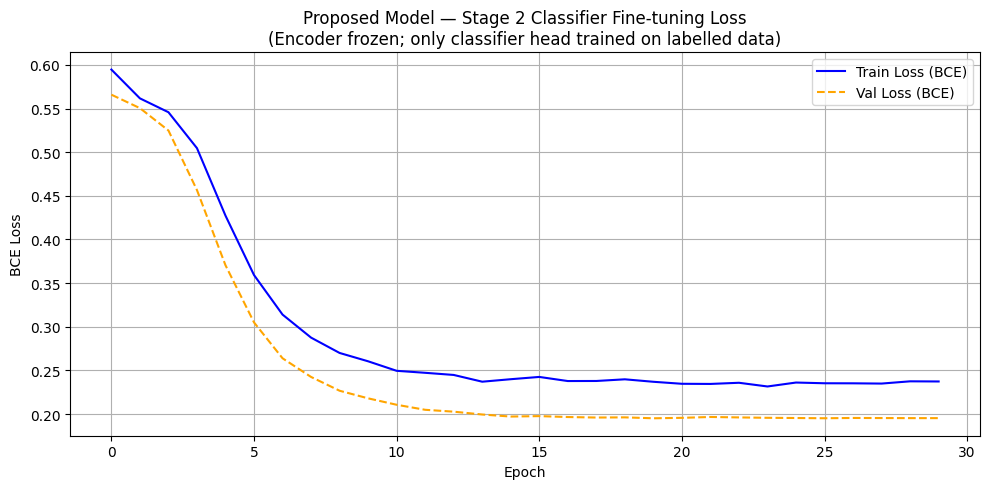


 Imbalance Sensitivity Analysis 
  Testing AUC across varying anomaly fractions.
  Anomaly fraction 5%  →  AUC = 0.9826
  Anomaly fraction 10%  →  AUC = 0.9765
  Anomaly fraction 20%  →  AUC = 0.9894
  Anomaly fraction 30%  →  AUC = 0.9813
  Anomaly fraction 40%  →  AUC = 0.9860
  (AUC stability across ratios validates imbalance robustness.)


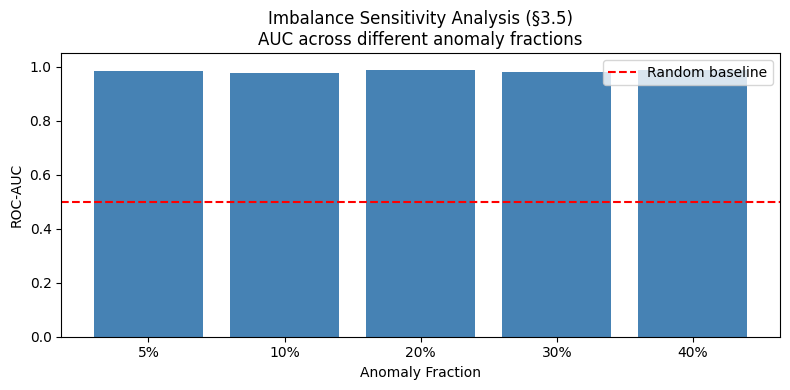


--- Threshold Sensitivity Analysis (§3.6) ---
  Selected threshold (Youden's J on val set): 0.7034
  t=0.6034 (Δ=-0.1)  Acc=0.9588  BalAcc=0.9588
  t=0.7034 (Δ=+0.0)  Acc=0.9606  BalAcc=0.9606 ← selected
  t=0.8034 (Δ=+0.1)  Acc=0.9591  BalAcc=0.9591


In [25]:
# Stage 2 — Classifier fine-tuning convergence plot
plt.figure(figsize=(10, 5))
plt.plot(clf_train_losses, label='Train Loss (BCE)', color='blue')
plt.plot(clf_val_losses,   label='Val Loss (BCE)',   color='orange', linestyle='--')
plt.title('Proposed Model — Stage 2 Classifier Fine-tuning Loss\n'
          '(Encoder frozen; only classifier head trained on labelled data)')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n Imbalance Sensitivity Analysis ")
print("  Testing AUC across varying anomaly fractions.")
ben_idx = np.where(y_test_arr == 0)[0]
att_idx = np.where(y_test_arr == 1)[0]
sensitivity_results = {}
for anomaly_frac in [0.05, 0.10, 0.20, 0.30, 0.40]:
    n_t = 2000
    n_a = min(int(n_t * anomaly_frac), len(att_idx))
    n_b = min(n_t - n_a, len(ben_idx))
    s_i = np.concatenate([np.random.choice(ben_idx, n_b, replace=False),
                           np.random.choice(att_idx, n_a, replace=False)])
    s_f, s_t, _ = roc_curve(y_test_arr[s_i], anomaly_scores[s_i])
    s_auc = auc(s_f, s_t)
    sensitivity_results[anomaly_frac] = s_auc
    print(f"  Anomaly fraction {anomaly_frac*100:.0f}%  →  AUC = {s_auc:.4f}")
print("  (AUC stability across ratios validates imbalance robustness.)")

# Sensitivity bar chart
plt.figure(figsize=(8, 4))
plt.bar([f'{int(k*100)}%' for k in sensitivity_results],
        list(sensitivity_results.values()), color='steelblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Random baseline')
plt.ylim(0, 1.05)
plt.title('Imbalance Sensitivity Analysis (§3.5)\n'
          'AUC across different anomaly fractions')
plt.xlabel('Anomaly Fraction'); plt.ylabel('ROC-AUC')
plt.legend(); plt.tight_layout(); plt.show()

# Threshold sensitivity analysis

print("\n--- Threshold Sensitivity Analysis (§3.6) ---")
print(f"  Selected threshold (Youden's J on val set): {best_threshold:.4f}")
for delta in [-0.1, 0.0, 0.1]:
    t_try   = np.clip(best_threshold + delta, 0.01, 0.99)
    preds_t = (anomaly_scores > t_try).astype(int)
    acc_t   = np.mean(preds_t == y_test_arr)
    bal_t   = balanced_accuracy_score(y_test_arr, preds_t)
    label   = ' ← selected' if delta == 0.0 else ''
    print(f"  t={t_try:.4f} (Δ={delta:+.1f})  "
          f"Acc={acc_t:.4f}  BalAcc={bal_t:.4f}{label}")

In [26]:
# Baseline Models
print(f'Baseline training shape : {X_train_scaled.shape}')
print(f'Baseline val shape      : {X_val_scaled.shape}')
print(f'Baseline test shape     : {X_test_scaled.shape}')
print(f'Class weights           : {class_weight_dict}')

# Building the LSTM Architecture
from tensorflow.keras.layers import GaussianNoise
lstm_model = Sequential([
    GaussianNoise(0.05, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    LSTM(128, return_sequences=False, dropout=0.2, recurrent_dropout=0.1),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


lstm_model.summary()

# Early Stopping Callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Baseline training shape : (138231, 1, 23)
Baseline val shape      : (19748, 1, 23)
Baseline test shape     : (39495, 1, 23)
Class weights           : {0: 1.0000072343196122, 1: 0.999992765785057}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 1, 23)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,145 (336.50 KB)

 Trainable params: 86,145 (336.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.6350 - loss: 0.6071 - val_accuracy: 0.6603 - val_loss: 0.5844
Epoch 2/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.6436 - loss: 0.5936 - val_accuracy: 0.6723 - val_loss: 0.5751
Epoch 3/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.6479 - loss: 0.5889 - val_accuracy: 0.6571 - val_loss: 0.5825
Epoch 4/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.6507 - loss: 0.5854 - val_accuracy: 0.6833 - val_loss: 0.5673
Epoch 5/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6536 - loss: 0.5823 - val_accuracy: 0.6843 - val_loss: 0.5646
Epoch 6/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.6594 - loss: 0.5791 - val_accuracy: 0.6815 - val_loss: 0.5648
Epoch 7/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.6631 - loss: 0.5762 - val_accuracy: 0.6832 - val_loss: 0.5582
Epoch 8/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.6651 - los

1235/1235 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Number of misclassified samples of the baseline Model (LSTM): 12343/39495
Accuracy of the baseline Model (LSTM): 0.6875
Error Rate of the baseline Model (LSTM): 0.3125
Prediction runtime of LSTM: 3.57 seconds


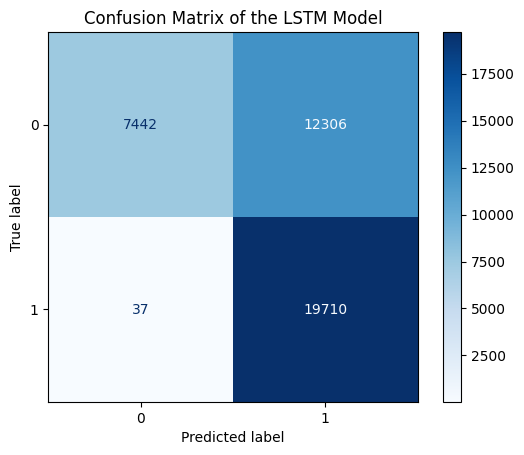

In [27]:
# Declaring variable for computing the runtime of the LSTM Model
start_pred = time.time()
y_pred_prob = lstm_model.predict(X_test_scaled)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculating the number of misclassified dataset samples
num_wrong = (y_pred != y_test).sum()

# Computing the Total number of test data samples
total_samples = len(y_test)

# Computing the error rate & accuracy of the LSTM Model
lstm_error_rate = num_wrong / total_samples
lstm_accuracy = 1 - lstm_error_rate

print(f"Number of misclassified samples of the baseline Model (LSTM): {num_wrong}/{total_samples}")
print(f"Accuracy of the baseline Model (LSTM): {lstm_accuracy:.4f}")
print(f"Error Rate of the baseline Model (LSTM): {lstm_error_rate:.4f}")

# Computing the end time for the LSTM Model in making a prediction
end_pred = time.time()

# Calculate elapsed time of the LSTM Model
lstm_pred_time = end_pred - start_pred
print(f"Prediction runtime of LSTM: {lstm_pred_time:.2f} seconds")
# Confusion Matrix of the LSTM Model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix of the LSTM Model")
plt.show()

In [28]:
# Importing libraries for the CNN Model
print(f'CNN training shape: {X_train_cnn.shape}')
print("CNN Input shape:", X_train_cnn.shape)
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    GaussianNoise(0.05),
    Conv1D(filters=32, kernel_size=3, activation='relu',
           kernel_regularizer=l2_reg(1e-4)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(filters=32, kernel_size=3, activation='relu',
           kernel_regularizer=l2_reg(1e-4)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2_reg(1e-4)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compiling the CNN MODEL
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn_model.summary()

history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

CNN training shape: (138231, 23, 1)
CNN Input shape: (138231, 23, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_1                │ (None, 23, 1)          │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 21, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,553 (45.13 KB)

 Trainable params: 11,553 (45.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.6453 - loss: 0.5992 - val_accuracy: 0.6886 - val_loss: 0.5709
Epoch 2/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.6717 - loss: 0.5732 - val_accuracy: 0.6897 - val_loss: 0.5473
Epoch 3/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6825 - loss: 0.5624 - val_accuracy: 0.6901 - val_loss: 0.5321
Epoch 4/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.6846 - loss: 0.5590 - val_accuracy: 0.6900 - val_loss: 0.5230
Epoch 5/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.6859 - loss: 0.5568 - val_accuracy: 0.6897 - val_loss: 0.5230
Epoch 6/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.6865 - loss: 0.5559 - val_accuracy: 0.6907 - val_loss: 0.5180
Epoch 7/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6872 - loss: 0.5536 - val_accuracy: 0.6897 - val_loss: 0.5176
Epoch 8/50
2160/2160 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.6877 - loss: 0

1235/1235 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Number of misclassified samples of the baseline Model (CNN): 12195/39495
Accuracy of the baseline Model (CNN): 0.6912
Error Rate of the baseline Model (CNN): 0.3088
Prediction runtime of the baseline Model CNN: 3.45 seconds


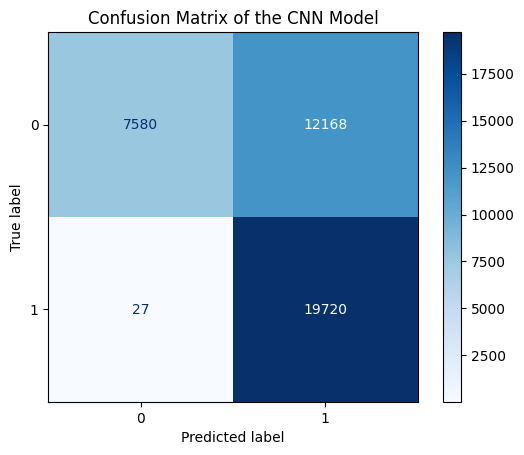

In [29]:

# Declaring variable for computing the runtime of the CNN Model
start_pred = time.time()
y_pred_prob = cnn_model.predict(X_test_cnn)

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculating the number of misclassified dataset samples
num_wrong = (y_pred != y_test).sum()

# Computing the Total number of test data samples
total_samples = len(y_test)

# Computing the error rate & accuracy of the CNN Model
cnn_error_rate = num_wrong / total_samples
cnn_accuracy = 1 - cnn_error_rate

print(f"Number of misclassified samples of the baseline Model (CNN): {num_wrong}/{total_samples}")
print(f"Accuracy of the baseline Model (CNN): {cnn_accuracy:.4f}")
print(f"Error Rate of the baseline Model (CNN): {cnn_error_rate:.4f}")

# Computing the end time for the CNN Model in making a prediction
end_pred = time.time()

# Calculate elapsed time of the CNN Model
pred_time = end_pred - start_pred
print(f"Prediction runtime of the baseline Model CNN: {pred_time:.2f} seconds")

# Confusion Matrix of the CNN Model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix of the CNN Model")
plt.show()

In [30]:
# Mult- Runs
N_RUNS = 5
SEEDS  = [42, 7, 13, 99, 2024][:N_RUNS]

# Storage for multi-run results
all_proposed_acc   = []
all_lstm_acc       = []
all_cnn_acc        = []
all_proposed_err   = []
all_lstm_err       = []
all_cnn_err        = []

print(f"\n=== Multi-run evaluation ({N_RUNS} seeds) ===")
for run_idx, seed in enumerate(SEEDS):
    print(f"\n--- Run {run_idx+1}/{N_RUNS} (seed={seed}) ---")
    set_seed(seed)

    # Stage 1: contrastive pre-training on ALL unlabelled data
    run_model    = ContrastiveModel(input_dim, latent_dim)
    run_opt_pt   = optim.Adam(run_model.parameters(), lr=0.001)
    run_sched_pt = optim.lr_scheduler.CosineAnnealingLR(
        run_opt_pt, T_max=num_epochs_pretrain, eta_min=1e-5)
    run_crit_pt  = NTXentLoss(temperature=0.5)
    for ep in range(num_epochs_pretrain):
        run_model.train()
        sub_idx_r = np.random.choice(len(X_pretrain_pool), size=SUBSAMPLE_SIZE, replace=False)
        sub_t_r   = torch.tensor(X_pretrain_pool[sub_idx_r], dtype=torch.float32)
        sub_ldr_r = DataLoader(TensorDataset(sub_t_r),
                               batch_size=batch_size, shuffle=True, drop_last=True)
        for (data,) in sub_ldr_r:
            ai, aj = augment_data(data)
            zi, zj = run_model(ai, aj)
            loss_  = run_crit_pt(zi, zj)
            run_opt_pt.zero_grad()
            loss_.backward()
            torch.nn.utils.clip_grad_norm_(run_model.parameters(), max_norm=1.0)
            run_opt_pt.step()
        run_sched_pt.step()

    # Stage 2: freeze encoder, train classifier head on labelled 2017 data
    for param in run_model.encoder.parameters():
        param.requires_grad = False
    run_clf = nn.Sequential(
        nn.Linear(latent_dim, 32), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(32, 1), nn.Sigmoid()
    )
    run_opt_clf  = optim.Adam(run_clf.parameters(), lr=0.001)
    run_crit_clf = nn.BCELoss()
    best_vl, best_clf_st = float('inf'), None
    pc = 0
    for ep in range(30):
        run_model.eval(); run_clf.train()
        for X_b, y_b in train_clf_loader:
            with torch.no_grad(): emb = run_model.encoder(X_b)
            pr  = run_clf(emb).squeeze()
            l_  = run_crit_clf(pr, y_b)
            run_opt_clf.zero_grad(); l_.backward(); run_opt_clf.step()
        run_clf.eval()
        vl = sum(run_crit_clf(run_clf(run_model.encoder(Xv)).squeeze(), yv).item()
                 for Xv, yv in val_clf_loader) / len(val_clf_loader)
        if vl < best_vl:
            best_vl = vl
            best_clf_st = {k: v.clone() for k, v in run_clf.state_dict().items()}
            pc = 0
        else:
            pc += 1
            if pc >= 10: break
    run_clf.load_state_dict(best_clf_st)

    # Stage 3: evaluate on 2018 test set
    run_model.eval(); run_clf.eval()
    run_probs = []
    with torch.no_grad():
        for X_b, _ in test_loader:
            run_probs.append(run_clf(run_model.encoder(X_b)).squeeze().cpu().numpy())
    run_probs    = np.concatenate(run_probs)
    run_pred     = (run_probs > 0.5).astype(int)
    run_prop_acc = np.mean(run_pred == y_test_arr)
    all_proposed_acc.append(run_prop_acc)
    all_proposed_err.append(1 - run_prop_acc)

    # Re-train LSTM baseline
    tf.random.set_seed(seed)
    np.random.seed(seed)
    Xr_flat   = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
    _yr_input = y_train
    n_minority_mr_lstm = int(np.sum(_yr_input == 1))
    print(f'Class distribution before SMOTE (mr_lstm): '
          f'benign={np.sum(_yr_input==0)}, anomaly={n_minority_mr_lstm}')
    if n_minority_mr_lstm < 2:
        print('  Fewer than 2 anomaly samples; using random oversampling.')
        _min_idx = np.where(_yr_input == 1)[0]
        _maj_idx = np.where(_yr_input == 0)[0]
        if len(_min_idx) == 0:
            raise ValueError('No anomaly samples — check data pipeline.')
        _over = np.random.choice(_min_idx, size=len(_maj_idx), replace=True)
        Xr_res = np.vstack([Xr_flat, Xr_flat[_over]])
        yr_res = np.concatenate([_yr_input, _yr_input[_over]])
        _shuf = np.random.permutation(len(yr_res))
        Xr_res, yr_res = Xr_res[_shuf], yr_res[_shuf]
    else:
        _k = min(5, n_minority_mr_lstm - 1)
        try:
            from imblearn.over_sampling import SMOTE
            _sm = SMOTE(random_state=seed, k_neighbors=_k)
            Xr_res, yr_res = _sm.fit_resample(Xr_flat, _yr_input)
        except ImportError:
            print('imbalanced-learn not installed; using random oversampling.')
            _min_idx = np.where(_yr_input == 1)[0]
            _maj_idx = np.where(_yr_input == 0)[0]
            _over = np.random.choice(_min_idx, size=len(_maj_idx), replace=True)
            Xr_res = np.vstack([Xr_flat, Xr_flat[_over]])
            yr_res = np.concatenate([_yr_input, _yr_input[_over]])
            _shuf = np.random.permutation(len(yr_res))
            Xr_res, yr_res = Xr_res[_shuf], yr_res[_shuf]
    print(f'Class distribution after  SMOTE (mr_lstm): '
          f'benign={np.sum(yr_res==0)}, anomaly={np.sum(yr_res==1)}')
    cw_r = compute_class_weight('balanced', classes=np.array([0,1]), y=yr_res)
    cw_dict_r = {0: cw_r[0], 1: cw_r[1]}
    Xr_3d = Xr_res.reshape(Xr_res.shape[0], 1, Xr_res.shape[1])
    run_lstm = Sequential([
        GaussianNoise(0.1, input_shape=(Xr_3d.shape[1], Xr_3d.shape[2])),
        LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.2),
        Dropout(0.4),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-3)),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    run_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    run_lstm.fit(Xr_3d, yr_res, validation_data=(X_test_scaled, y_test),
                 epochs=50, batch_size=256, class_weight=cw_dict_r,
                 callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                 verbose=0)
    lstm_prob = run_lstm.predict(X_test_scaled, verbose=0)
    lstm_pred_run = (lstm_prob > 0.5).astype(int).flatten()
    run_lstm_acc = np.mean(lstm_pred_run == y_test_arr)
    all_lstm_acc.append(run_lstm_acc)
    all_lstm_err.append(1 - run_lstm_acc)

    # Re-train CNN baseline
    tf.random.set_seed(seed)
    np.random.seed(seed)
    Xr_cnn_3d = Xr_3d  # reuse SMOTE output from LSTM run above (same seed)
    Xr_cnn = np.transpose(Xr_cnn_3d, (0, 2, 1))
    run_cnn = Sequential([
        Input(shape=(Xr_cnn.shape[1], Xr_cnn.shape[2])),
        GaussianNoise(0.1),
        Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-3)),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),
        Conv1D(filters=64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-3)),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),
        Flatten(),
        Dense(16, activation='relu', kernel_regularizer=l2(1e-3)),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    run_cnn.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    run_cnn.fit(Xr_cnn, yr_res, validation_data=(X_test_cnn, y_test),
                epochs=50, batch_size=256, class_weight=cw_dict_r,
                callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                verbose=0)
    cnn_prob = run_cnn.predict(X_test_cnn, verbose=0)
    cnn_pred_run = (cnn_prob > 0.5).astype(int).flatten()
    run_cnn_acc = np.mean(cnn_pred_run == y_test_arr)
    all_cnn_acc.append(run_cnn_acc)
    all_cnn_err.append(1 - run_cnn_acc)

    print(f"  Proposed acc={run_prop_acc:.4f} | LSTM acc={run_lstm_acc:.4f} | CNN acc={run_cnn_acc:.4f}")


=== Multi-run evaluation (5 seeds) ===

--- Run 1/5 (seed=42) ---
Class distribution before SMOTE (mr_lstm): benign=69115, anomaly=69116
Class distribution after  SMOTE (mr_lstm): benign=69116, anomaly=69116


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Proposed acc=0.9579 | LSTM acc=0.6304 | CNN acc=0.6442

--- Run 2/5 (seed=7) ---
Class distribution before SMOTE (mr_lstm): benign=69115, anomaly=69116
Class distribution after  SMOTE (mr_lstm): benign=69116, anomaly=69116


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Proposed acc=0.9563 | LSTM acc=0.6312 | CNN acc=0.6661

--- Run 3/5 (seed=13) ---
Class distribution before SMOTE (mr_lstm): benign=69115, anomaly=69116
Class distribution after  SMOTE (mr_lstm): benign=69116, anomaly=69116


...

  Proposed acc=0.9556 | LSTM acc=0.6301 | CNN acc=0.6334

--- Run 4/5 (seed=99) ---
Class distribution before SMOTE (mr_lstm): benign=69115, anomaly=69116
Class distribution after  SMOTE (mr_lstm): benign=69116, anomaly=69116


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Proposed acc=0.9564 | LSTM acc=0.6304 | CNN acc=0.6647

--- Run 5/5 (seed=2024) ---
Class distribution before SMOTE (mr_lstm): benign=69115, anomaly=69116
Class distribution after  SMOTE (mr_lstm): benign=69116, anomaly=69116


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Proposed acc=0.9558 | LSTM acc=0.6301 | CNN acc=0.6371


In [31]:
# Summary statistics
print("\n=== Summary (mean ± std across runs) ===")
print(f"Proposed model  accuracy : {np.mean(all_proposed_acc):.4f} ± {np.std(all_proposed_acc):.4f}")
print(f"LSTM baseline   accuracy : {np.mean(all_lstm_acc):.4f} ± {np.std(all_lstm_acc):.4f}")
print(f"CNN baseline    accuracy : {np.mean(all_cnn_acc):.4f} ± {np.std(all_cnn_acc):.4f}")
print(f"Proposed model  error    : {np.mean(all_proposed_err):.4f} ± {np.std(all_proposed_err):.4f}")
print(f"LSTM baseline   error    : {np.mean(all_lstm_err):.4f} ± {np.std(all_lstm_err):.4f}")
print(f"CNN baseline    error    : {np.mean(all_cnn_err):.4f} ± {np.std(all_cnn_err):.4f}")


=== Summary (mean ± std across runs) ===
Proposed model  accuracy : 0.9564 ± 0.0008
LSTM baseline   accuracy : 0.6305 ± 0.0004
CNN baseline    accuracy : 0.6491 ± 0.0137
Proposed model  error    : 0.0436 ± 0.0008
LSTM baseline   error    : 0.3695 ± 0.0004
CNN baseline    error    : 0.3509 ± 0.0137


In [32]:
# Hypothesis 1: Error rate (Wilcoxon signed-rank test)
print("\n Hypothesis 1: Error Rate (Wilcoxon signed-rank test)")
if len(set(np.array(all_proposed_err) - np.array(all_lstm_err))) > 1:
    stat, p_val = wilcoxon(all_proposed_err, all_lstm_err)
    print(f"  Proposed vs LSTM  — W={stat:.4f}, p={p_val:.4f} {'=> reject H0 (p<0.05)' if p_val < 0.05 else '=> fail to reject H0'}")
else:
    print("  Proposed vs LSTM  — all differences identical; test not applicable.")
if len(set(np.array(all_proposed_err) - np.array(all_cnn_err))) > 1:
    stat, p_val = wilcoxon(all_proposed_err, all_cnn_err)
    print(f"  Proposed vs CNN   — W={stat:.4f}, p={p_val:.4f} {'=> reject H0 (p<0.05)' if p_val < 0.05 else '=> fail to reject H0'}")
else:
    print("  Proposed vs CNN   — all differences identical; test not applicable.")


 Hypothesis 1: Error Rate (Wilcoxon signed-rank test)
  Proposed vs LSTM  — W=0.0000, p=0.0625 => fail to reject H0
  Proposed vs CNN   — W=0.0000, p=0.0625 => fail to reject H0


In [33]:
# Hypothesis 2: Accuracy (Wilcoxon signed-rank test)
print("\n Hypothesis 2: Accuracy (Wilcoxon signed-rank test)")
if len(set(np.array(all_proposed_acc) - np.array(all_lstm_acc))) > 1:
    stat, p_val = wilcoxon(all_proposed_acc, all_lstm_acc)
    print(f"  Proposed vs LSTM  — W={stat:.4f}, p={p_val:.4f} {'=> reject H0 (p<0.05)' if p_val < 0.05 else '=> fail to reject H0'}")
else:
    print("  Proposed vs LSTM  — all differences identical; test not applicable.")
if len(set(np.array(all_proposed_acc) - np.array(all_cnn_acc))) > 1:
    stat, p_val = wilcoxon(all_proposed_acc, all_cnn_acc)
    print(f"  Proposed vs CNN   — W={stat:.4f}, p={p_val:.4f} {'=> reject H0 (p<0.05)' if p_val < 0.05 else '=> fail to reject H0'}")
else:
    print("  Proposed vs CNN   — all differences identical; test not applicable.")


 Hypothesis 2: Accuracy (Wilcoxon signed-rank test)
  Proposed vs LSTM  — W=0.0000, p=0.0625 => fail to reject H0
  Proposed vs CNN   — W=0.0000, p=0.0625 => fail to reject H0


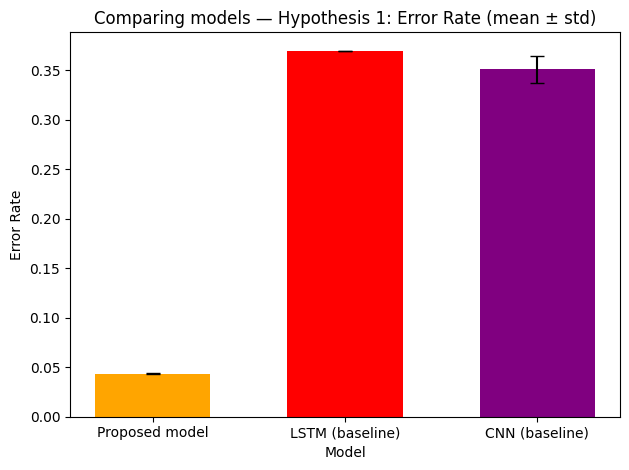

In [34]:
#  Bar charts use multi-run means
proposed_Model_accuracy   = np.mean(all_proposed_acc)
proposed_Model_error_rate = np.mean(all_proposed_err)
lstm_accuracy  = np.mean(all_lstm_acc)
lstm_error_rate = np.mean(all_lstm_err)
cnn_accuracy   = np.mean(all_cnn_acc)
cnn_error_rate = np.mean(all_cnn_err)

error_rate_labels = ['Proposed model', 'LSTM (baseline)', 'CNN (baseline)']
error_rate_values = [proposed_Model_error_rate, lstm_error_rate, cnn_error_rate]
error_rate_stds   = [np.std(all_proposed_err), np.std(all_lstm_err), np.std(all_cnn_err)]
colors = ['orange', 'red', 'purple']
plt.bar(error_rate_labels, error_rate_values, color=colors, width=0.6, yerr=error_rate_stds, capsize=5)
plt.title('Comparing models — Hypothesis 1: Error Rate (mean ± std)')
plt.xlabel('Model')
plt.ylabel('Error Rate')
plt.tight_layout()
plt.show()

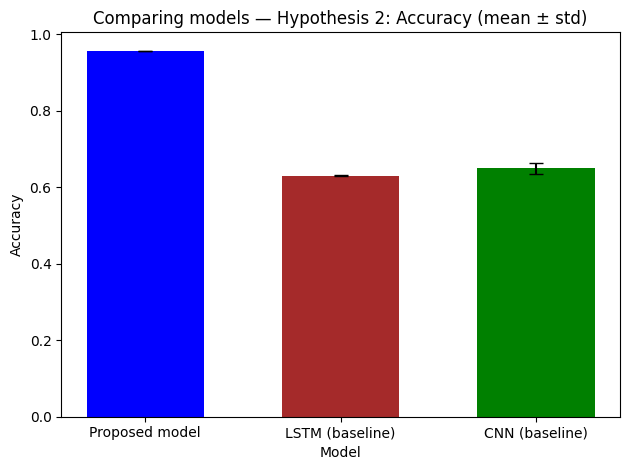

In [35]:

accuracy_labels = ['Proposed model', 'LSTM (baseline)', 'CNN (baseline)']
accuracy_values = [proposed_Model_accuracy, lstm_accuracy, cnn_accuracy]
accuracy_stds   = [np.std(all_proposed_acc), np.std(all_lstm_acc), np.std(all_cnn_acc)]
colors = ['blue', 'brown', 'green']
# CORRECTED (§4.2): Bar height is now the mean over N_RUNS; error bars show std.
# This replaces the original single-run point estimate.
plt.bar(accuracy_labels, accuracy_values, color=colors, width=0.6, yerr=accuracy_stds, capsize=5)
plt.title('Comparing models — Hypothesis 2: Accuracy (mean ± std)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

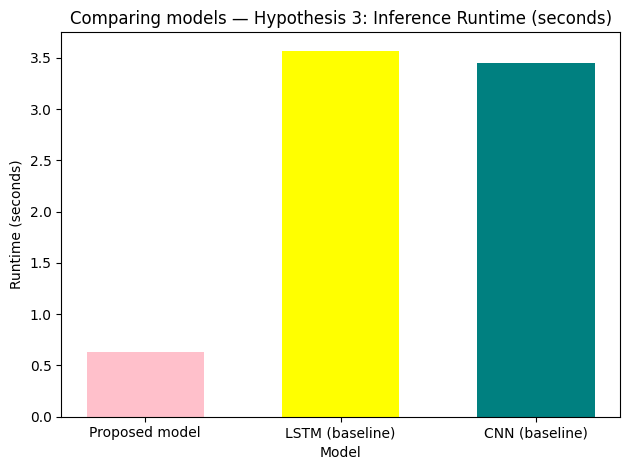

In [36]:

runtime_labels = ['Proposed model', 'LSTM (baseline)', 'CNN (baseline)']
runtime_values = [elapsed_time, lstm_pred_time, pred_time]
colors = ['pink', 'yellow', 'teal']
plt.bar(runtime_labels, runtime_values, color=colors, width=0.6)
plt.title('Comparing models — Hypothesis 3: Inference Runtime (seconds)')
plt.xlabel('Model')
plt.ylabel('Runtime (seconds)')
plt.tight_layout()
plt.show()

In [40]:
print("CROSS-DOMAIN ABLATION STUDY ")
print("="*70)
print("Comparing: Network-only | Financial-only | Combined (concatenated)")
print("Architecture identical across all conditions — only input domain varies.")
print("="*70)

from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def run_ablation_condition(X_data, y_data, condition_name, encoder, latent_dim,
                            encoder_input_dim, scaler_fit=True):
    """
    Train classifier head on condition data and report AUC + accuracy.
    Uses the pre-trained contrastive encoder (frozen) from Stage 1.
    encoder_input_dim: slice X to this many features to match encoder's input layer.
    """
    print(f"\n--- Condition: {condition_name} ---")

    # ── Slice features to match encoder input dimension ───────────────────────
    # X_data may have more columns than the encoder expects (e.g. 30 vs 23).
    # Slice to encoder_input_dim so linear layer shapes are compatible.
    X_data = X_data[:, :encoder_input_dim]
    print(f"  Input features: {X_data.shape[1]} → adjusted to {encoder_input_dim}")

    # Balance classes
    n_b = int((y_data==0).sum()); n_a = int((y_data==1).sum())
    n_e = min(n_b, n_a)
    if n_e == 0:
        print(f"  Skipping — no minority class samples.")
        return None, None
    b_idx = np.random.choice(np.where(y_data==0)[0], n_e, replace=False)
    a_idx = np.random.choice(np.where(y_data==1)[0], n_e, replace=False)
    sel   = np.concatenate([b_idx, a_idx])
    np.random.shuffle(sel)
    X_bal = X_data[sel]; y_bal = y_data[sel]

    # Split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_bal, y_bal, test_size=0.20, random_state=42, stratify=y_bal)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr,  y_tr,  test_size=0.125, random_state=42, stratify=y_tr)

    # Scale
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_va_s = sc.transform(X_va)
    X_te_s = sc.transform(X_te)

    # Tensors
    Xtr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr.astype(np.float32))
    Xva_t = torch.tensor(X_va_s, dtype=torch.float32)
    yva_t = torch.tensor(y_va.astype(np.float32))
    Xte_t = torch.tensor(X_te_s, dtype=torch.float32)

    tr_ldr = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=256, shuffle=True)
    va_ldr = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=256, shuffle=False)

    # Classifier head (same architecture as main model)
    abl_clf = nn.Sequential(
        nn.Linear(latent_dim, 32), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(32, 1), nn.Sigmoid()
    )
    abl_opt  = optim.Adam(abl_clf.parameters(), lr=0.001)
    abl_crit = nn.BCELoss()
    best_vl, best_st, pc = float('inf'), None, 0

    encoder.eval()
    for ep in range(30):
        abl_clf.train()
        for Xb, yb in tr_ldr:
            with torch.no_grad(): emb = encoder(Xb)
            pr  = abl_clf(emb).squeeze()
            l   = abl_crit(pr, yb)
            abl_opt.zero_grad(); l.backward(); abl_opt.step()
        abl_clf.eval()
        vl = sum(abl_crit(abl_clf(encoder(Xb)).squeeze(), yb).item()
                 for Xb, yb in va_ldr) / len(va_ldr)
        if vl < best_vl:
            best_vl = vl
            best_st = {k: v.clone() for k, v in abl_clf.state_dict().items()}
            pc = 0
        else:
            pc += 1
            if pc >= 10: break
    abl_clf.load_state_dict(best_st)

    # Evaluate
    abl_clf.eval()
    with torch.no_grad():
        probs = abl_clf(encoder(Xte_t)).squeeze().numpy()
    preds = (probs > 0.5).astype(int)
    acc   = float(np.mean(preds == y_te))
    auc_s = float(roc_auc_score(y_te, probs))
    bal   = float(balanced_accuracy_score(y_te, preds))
    print(f"  Test samples : {len(y_te)} (benign={(y_te==0).sum()}, attack={(y_te==1).sum()})")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  Balanced Acc : {bal:.4f}")
    print(f"  ROC-AUC      : {auc_s:.4f}")
    return acc, auc_s

# encoder_input_dim = the actual input_dim the encoder was built with
encoder_input_dim = input_dim   # defined when model was created

ablation_results = {}

acc_net, auc_net = run_ablation_condition(
    X_network_domain, y_network_domain,
    "Network only (CIC-IDS-2017 + 2018)",
    model.encoder, latent_dim, encoder_input_dim
)
ablation_results['Network only'] = (acc_net, auc_net)

acc_fin, auc_fin = run_ablation_condition(
    X_financial_domain, y_financial_domain,
    "Financial only (synthetic, zero-padded)",
    model.encoder, latent_dim, encoder_input_dim
)
ablation_results['Financial only'] = (acc_fin, auc_fin)

acc_comb, auc_comb = run_ablation_condition(
    X_combined_domain, y_combined_domain,
    "Combined — concatenated (proposed architecture)",
    model.encoder, latent_dim, encoder_input_dim
)
ablation_results['Combined'] = (acc_comb, auc_comb)

CROSS-DOMAIN ABLATION STUDY 
Comparing: Network-only | Financial-only | Combined (concatenated)
Architecture identical across all conditions — only input domain varies.

--- Condition: Network only (CIC-IDS-2017 + 2018) ---
  Input features: 23 → adjusted to 23
  Test samples : 39495 (benign=19748, attack=19747)
  Accuracy     : 0.9633
  Balanced Acc : 0.9633
  ROC-AUC      : 0.9866

--- Condition: Financial only (synthetic, zero-padded) ---
  Input features: 23 → adjusted to 23
  Test samples : 1000 (benign=500, attack=500)
  Accuracy     : 1.0000
  Balanced Acc : 1.0000
  ROC-AUC      : 1.0000

--- Condition: Combined — concatenated (proposed architecture) ---
  Input features: 23 → adjusted to 23
  Test samples : 54247 (benign=27124, attack=27123)
  Accuracy     : 0.6582
  Balanced Acc : 0.6582
  ROC-AUC      : 0.7466


In [41]:

# Summary table

print("ABLATION STUDY SUMMARY (§3.3)")
print("="*70)
print(f"{'Condition':<40} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-"*70)
for cond, (acc, auc_v) in ablation_results.items():
    if acc is not None:
        print(f"{cond:<40} {acc:>10.4f} {auc_v:>10.4f}")


ABLATION STUDY SUMMARY (§3.3)
Condition                                  Accuracy    ROC-AUC
----------------------------------------------------------------------
Network only                                 0.9633     0.9866
Financial only                               1.0000     1.0000
Combined                                     0.6582     0.7466


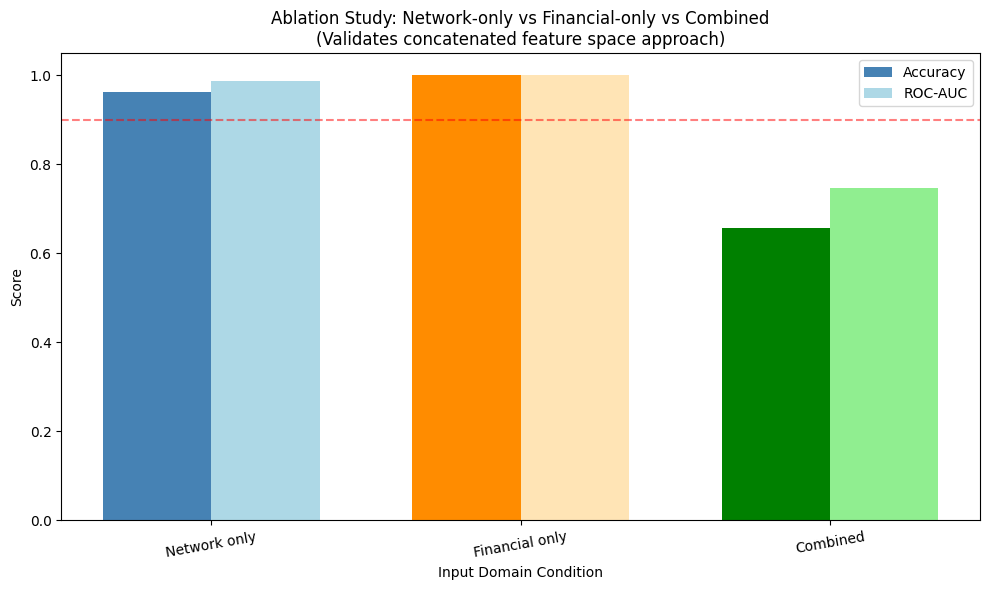

In [42]:
# Bar chart: Ablation results
conditions = list(ablation_results.keys())
accs  = [ablation_results[c][0] for c in conditions if ablation_results[c][0] is not None]
aucs  = [ablation_results[c][1] for c in conditions if ablation_results[c][1] is not None]
conds = [c for c in conditions if ablation_results[c][0] is not None]

x = np.arange(len(conds))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, accs, width, label='Accuracy', color=['steelblue','darkorange','green'])
ax.bar(x + width/2, aucs, width, label='ROC-AUC',  color=['lightblue','moccasin','lightgreen'])
ax.set_xlabel('Input Domain Condition')
ax.set_ylabel('Score')
ax.set_title('Ablation Study: Network-only vs Financial-only vs Combined\n'
             '(Validates concatenated feature space approach)')
ax.set_xticks(x)
ax.set_xticklabels(conds, rotation=10)
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='90% reference')
plt.tight_layout()
plt.show()